# Cityflo Mobility Analysis — GPS Audit

This notebook focuses on profiling and validating the raw GPS telemetry data before any cleaning rules are implemented.

Goals:

- Profile GPS data quality and coverage
- Quantify missing values and anomalies
- Evaluate candidate filtering rules
- Measure temporal and vehicle coverage
- Determine segmentation parameters
- Produce an evidence-based GPS cleaning specification

**Important:** No cleaning rule should be applied unless its impact has been quantified first.

## Section 5 — GPS Profiling

Load 500k rows (streaming). Validate schema, measure null rates, characterise every column.

In [2]:
from pathlib import Path
from collections import Counter
import re, json, yaml
import numpy as np
import pandas as pd
import polars as pl
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

RAW       = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES   = Path("../outputs/figures/eda")
FIGURES.mkdir(parents=True, exist_ok=True)

GPS_FILES = [
    RAW / "before_2022-10-22_698096e5f4994518a37a0b9c59bb9756",
    RAW / "before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part2",
    RAW / "before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part3",
]

LEGACY_COLS = [
    "id",           # pos 1  — unique int, sequential
    "lat",          # pos 2
    "lng",          # pos 3
    "created",      # pos 4  — ingestion timestamp UTC
    "vehicle_id",   # pos 5
    "timestamp",    # pos 6  — GPS event timestamp UTC  ← USE THIS
    "speed",        # pos 7  — km/h; 699.999 / 602 = sentinels
    "bearing",      # pos 8  — compass degrees 0-360
    "source",       # pos 9  — 1/2=OBD, 4=GPS tracker
    "c10",          # pos 10 — confirmed always empty → drop
    "c11",          # pos 11 — values {1,4,5} — structured, keep
    "deviation_s",  # pos 12 — GPS vs DB time diff seconds
    "c13",          # pos 13 — sparse (sometimes "0" or "2")
    "c14",          # pos 14 — near-constant "1"
]
LEGACY_DTYPES = {
    "id": pl.Int64, "lat": pl.Float64, "lng": pl.Float64,
    "created": pl.Utf8, "vehicle_id": pl.Int64, "timestamp": pl.Utf8,
    "speed": pl.Float64, "bearing": pl.Float64, "source": pl.Int32,
    "c10": pl.Utf8, "c11": pl.Utf8,
    "deviation_s": pl.Float64,
    "c13": pl.Utf8, "c14": pl.Utf8,
}

MUMBAI_BBOX = {
    "lat_min": 18.8894,
    "lat_max": 19.3274,
    "lng_min": 72.7692,
    "lng_max": 73.1165,
}

N_SAMPLE = 500_000

print(f"Loading {N_SAMPLE:,} rows from GPS file 1 (streaming, no RAM spike)...")
sample_lf = pl.scan_csv(
    GPS_FILES[0],
    has_header=False,
    new_columns=LEGACY_COLS,
    schema_overrides=LEGACY_DTYPES,
    ignore_errors=True,
    infer_schema_length=0,
    null_values=["", "NULL", "null"],
    truncate_ragged_lines=True,
    n_rows=N_SAMPLE,
)
gps = sample_lf.collect()
print(f"Loaded: {len(gps):,} rows × {len(gps.columns)} columns")
print(f"Columns: {gps.columns}")

# NULL RATES
print("\nNULL RATES (per column):")
for col in gps.columns:
    rate = gps[col].null_count() / len(gps)
    bar = "█" * int(rate * 40)
    flag = (
        " ← ALWAYS NULL — drop"
        if rate == 1.0
        else (" ← mostly null" if rate > 0.5 else "")
    )
    print(f"  {col:15s} {100*rate:5.1f}%  {bar}{flag}")

Loading 500,000 rows from GPS file 1 (streaming, no RAM spike)...
Loaded: 500,000 rows × 14 columns
Columns: ['id', 'lat', 'lng', 'created', 'vehicle_id', 'timestamp', 'speed', 'bearing', 'source', 'c10', 'c11', 'deviation_s', 'c13', 'c14']

NULL RATES (per column):
  id                0.0%  
  lat               0.0%  
  lng               0.0%  
  created           0.0%  
  vehicle_id        0.0%  
  timestamp         0.0%  
  speed            14.8%  █████
  bearing          14.8%  █████
  source            0.0%  
  c10             100.0%  ████████████████████████████████████████ ← ALWAYS NULL — drop
  c11               0.0%  
  deviation_s       0.1%  
  c13              23.1%  █████████
  c14               0.0%  


c11 — non-null: 500,000 / 500,000 (100.0%)

Unique values:
['1', '2', '4']

Value counts:
c11  count
  4 409880
  1  89991
  2    129

Range: min=1, max=4, mean=3.46

Speed — non-null: 426,017 | null: 73,983

Values >150 km/h:
   speed  count
 699.999   3323
 500.000    905
1000.000    897
 602.000    757
 600.000    642
 800.000    515
1200.000    441
 899.999    328
1100.000    118
 300.000    117
 632.000    108
 671.000     95
 687.000     87
 674.000     64
 669.000     59
 659.000     45
 604.000     40
 621.000     38
 652.000     37
 627.000     26

Percentiles:
  p 50.0: 3.900 km/h
  p 90.0: 37.660 km/h
  p 95.0: 88.780 km/h


  p 99.0: 699.999 km/h
  p 99.5: 800.000 km/h
  p 99.9: 1200.000 km/h

Rows >150 km/h: 10,874 (2.55% of non-null speeds)

Most frequent values >150 km/h:
   speed  count  pct_non_null_speed
 699.999   3323            0.780016
 500.000    905            0.212433
1000.000    897            0.210555
 602.000    757            0.177692
 600.000    642            0.150698
 800.000    515            0.120887
1200.000    441            0.103517
 899.999    328            0.076992
1100.000    118            0.027698
 300.000    117            0.027464


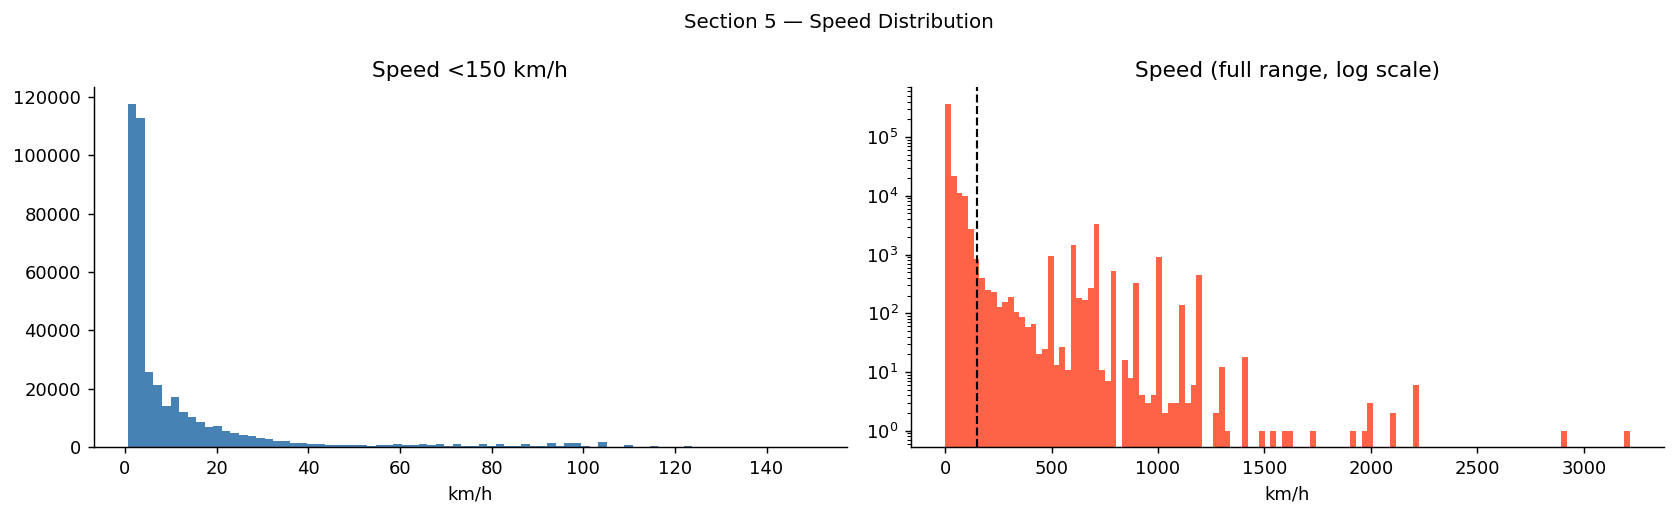

In [12]:
# c11 distribution
c11_raw = gps["c11"].drop_nulls()

print(f"c11 — non-null: {len(c11_raw):,} / {len(gps):,} ({100 * len(c11_raw) / len(gps):.1f}%)")

print("\nUnique values:")
print(sorted(c11_raw.unique().cast(pl.Utf8).to_list()))

print("\nValue counts:")
print(c11_raw.value_counts().sort("count", descending=True).to_pandas().to_string(index=False))

try:
    c11_int = c11_raw.cast(pl.Int32, strict=False).drop_nulls()
    print(f"\nRange: min={c11_int.min()}, max={c11_int.max()}, mean={c11_int.mean():.2f}")
except Exception:
    pass


# Speed distribution
spd = gps["speed"].drop_nulls()
print(f"\nSpeed — non-null: {len(spd):,} | null: {gps['speed'].null_count():,}")

upper = spd.filter(spd > 150)
print("\nValues >150 km/h:")
if len(upper) > 0:
    print(upper.value_counts().sort("count", descending=True).head(20).to_pandas().to_string(index=False))
else:
    print("None")

print("\nPercentiles:")
for p in [50, 90, 95, 99, 99.5, 99.9]:
    print(f"  p{p:5.1f}: {spd.quantile(p / 100, interpolation='nearest'):.3f} km/h")

print(f"\nRows >150 km/h: {len(upper):,} ({100 * len(upper) / len(spd):.2f}% of non-null speeds)")

# Top repeated values above threshold
if len(upper) > 0:
    sentinel_summary = (
        upper
        .value_counts()
        .sort("count", descending=True)
        .with_columns(
            (
                pl.col("count") / len(spd) * 100
            ).alias("pct_non_null_speed")
        )
    )
    print("\nMost frequent values >150 km/h:")
    print(sentinel_summary.head(10).to_pandas().to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
spd_pd = spd.to_pandas()
axes[0].hist(spd_pd[spd_pd < 150], bins=80,color="steelblue", edgecolor="none")
axes[0].set_title("Speed <150 km/h")
axes[0].set_xlabel("km/h")
axes[1].hist(spd_pd, bins=120, color="tomato", edgecolor="none", log=True)
axes[1].axvline(150, color="black", linestyle="--", linewidth=1.2)
axes[1].set_title("Speed (full range, log scale)")
axes[1].set_xlabel("km/h")
plt.suptitle("Section 5 — Speed Distribution", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "5_speed_distribution.png", bbox_inches="tight")
plt.show()

Bearing — non-null: 426,017  range: [0.0, 100.0]
  Values restricted to 0–100; does NOT appear to be true 0–360 compass heading


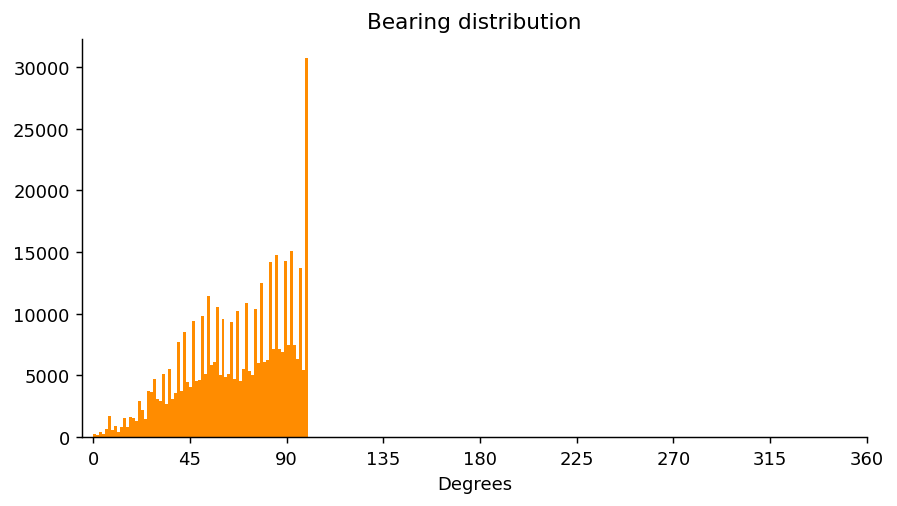

Source distribution:
 source  count
      1 493318
      2   6682

Unique source values: 2
Unexpected source values: 0

Unique vehicles : 120
Null vehicle_id : 0

Pings per vehicle — top 20:
 vehicle_id  count
        653  16515
        380  13731
        667  13547
        751  13195
        657  13100
        565  12436
        599  10798
        614  10608
        536   9810
        600   9344
       1061   8612
        735   7899
       1820   7784
        640   7227
        655   6826
        656   6488
        654   6473
        658   6299
        679   6254
        676   6237

Pings per vehicle — percentiles:
  p 10: 5
  p 25: 1697
  p 50: 4104
  p 75: 5592
  p 90: 7784
  p 95: 10798
  p 99: 13731

deviation_s — non-null: 499,343 | null: 657
Range: [0.0, 1160428.0] seconds

Deviation thresholds:
  |deviation| >    60s : 6,609 (1.324%)
  |deviation| >   120s : 1,025 (0.205%)
  |deviation| >   300s : 469 (0.094%)
  |deviation| >   600s : 286 (0.057%)
  |deviation| >  3600s : 238 (

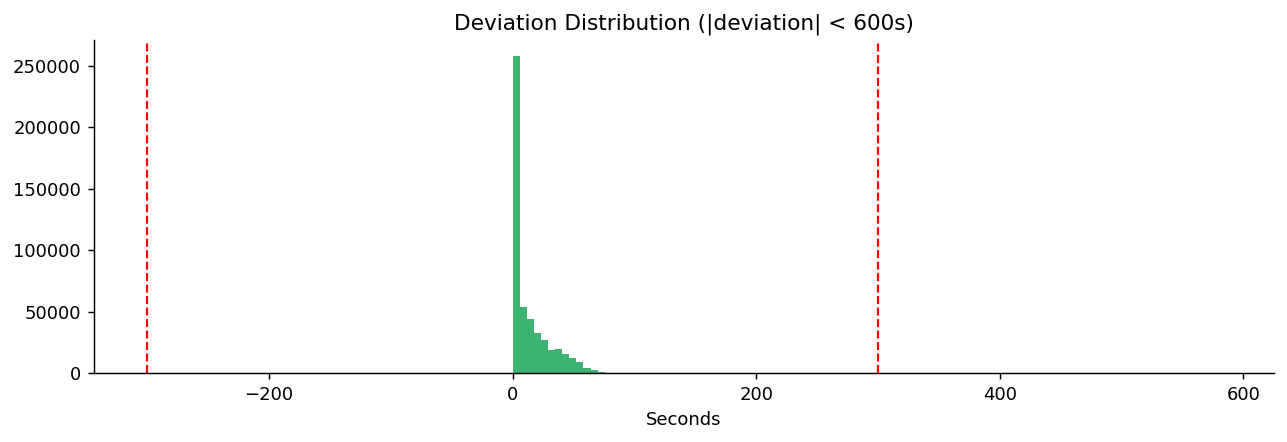

In [13]:
# BEARING column
brg = gps["bearing"].drop_nulls()
print(f"Bearing — non-null: {len(brg):,}  range: [{brg.min():.1f}, {brg.max():.1f}]")
if brg.max() <= 100:
    print("  Values restricted to 0–100; does NOT appear to be true 0–360 compass heading")
elif brg.max() <= 360 and brg.min() >= 0:
    print("  Valid compass degrees (0–360)")
else:
    print("  Values outside 0–360 — flag for investigation")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(brg.to_pandas(), bins=72, color="darkorange", edgecolor="none")  # 5° bins
ax.set_title("Bearing distribution")
ax.set_xlabel("Degrees")
ax.set_xticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
plt.tight_layout()
plt.savefig(FIGURES / "5_bearing_distribution.png", bbox_inches="tight")
plt.show()


# SOURCE column
src = gps["source"].drop_nulls()

print("Source distribution:")
print(src.value_counts().sort("source").to_pandas().to_string(index=False))

print(f"\nUnique source values: {src.n_unique()}")

unexpected = src.filter(~src.is_in([1, 2, 4]))
print(f"Unexpected source values: {len(unexpected):,}")

if len(unexpected) > 0:
    print(unexpected.value_counts().to_pandas().to_string(index=False))


# VEHICLE_ID coverage
vids = gps["vehicle_id"].drop_nulls()

print(f"\nUnique vehicles : {vids.n_unique():,}")
print(f"Null vehicle_id : {gps['vehicle_id'].null_count():,}")

vc = gps["vehicle_id"].value_counts().sort("count", descending=True)

print("\nPings per vehicle — top 20:")
print(vc.head(20).to_pandas().to_string(index=False))

counts = vc["count"]

print("\nPings per vehicle — percentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:3d}: {counts.quantile(p/100, interpolation='nearest'):.0f}")


# DEVIATION_S column
dev = gps["deviation_s"].drop_nulls()

print(f"\ndeviation_s — non-null: {len(dev):,} | null: {gps['deviation_s'].null_count():,}")
print(f"Range: [{dev.min():.1f}, {dev.max():.1f}] seconds")

print("\nDeviation thresholds:")
for t in [60, 120, 300, 600, 3600]:
    n = (dev.abs() > t).sum()
    print(f"  |deviation| > {t:5d}s : {n:,} ({100*n/len(dev):.3f}%)")

print("\nDeviation percentiles:")
for p in [50, 90, 95, 99, 99.5, 99.9, 99.99]:
    print(f"  p{p:6.2f}: {dev.quantile(p/100, interpolation='nearest'):.1f}s")

print("\nLargest deviation values:")
print(
    dev.sort(descending=True)
       .head(20)
       .to_frame()
       .to_pandas()
       .to_string(index=False)
)

fig, ax = plt.subplots(figsize=(10, 3.5))

dev_pd = dev.to_pandas()
clip = dev_pd[dev_pd.abs() < 600]

ax.hist(clip, bins=100, color="mediumseagreen", edgecolor="none")
ax.axvline(300, color="red", ls="--", lw=1.2)
ax.axvline(-300, color="red", ls="--", lw=1.2)

ax.set_title("Deviation Distribution (|deviation| < 600s)")
ax.set_xlabel("Seconds")

plt.tight_layout()
plt.savefig(FIGURES / "5_deviation_distribution.png", bbox_inches="tight")
plt.show()

In [ ]:
print("\nRows above candidate thresholds:")

for t in [80, 100, 120, 150, 200, 300]:
    n = (spd > t).sum()
    print(f"  > {t:3d} km/h : " f"{n:7,} ({100*n/len(spd):6.3f}%)")


Rows above candidate thresholds:
  >  80 km/h :  24,103 ( 5.658%)
  > 100 km/h :  16,372 ( 3.843%)
  > 120 km/h :  12,322 ( 2.892%)
  > 150 km/h :  10,874 ( 2.552%)
  > 200 km/h :  10,057 ( 2.361%)
  > 300 km/h :   9,288 ( 2.180%)


Valid timestamps : 500,000 / 500,000 (100.00%)
Date range (UTC) : 2021-09-01 12:52:57+00:00 → 2022-10-01 06:39:51+00:00
Date range (IST) : 2021-09-01 18:22:57+05:30 → 2022-10-01 12:09:51+05:30
Pings outside Mumbai bbox : 2,822 (0.56%)
Lat range : [0.00000, 28.50486]
Lng range : [0.00000, 77.19492]

Sample of out-of-bbox pings (first 10):
         lat        lng  speed  source
0  18.985270  73.125080    NaN       1
1  18.985270  73.125080    NaN       1
2  18.985270  73.125080    NaN       2
3  18.985270  73.125080    NaN       2
4  18.985270  73.125080    NaN       2
5  18.985270  73.125080    NaN       1
6  18.985270  73.125080    NaN       2
7  18.985270  73.125080    NaN       2
8  28.479588  77.034832    NaN       1
9  18.985270  73.125080    NaN       2


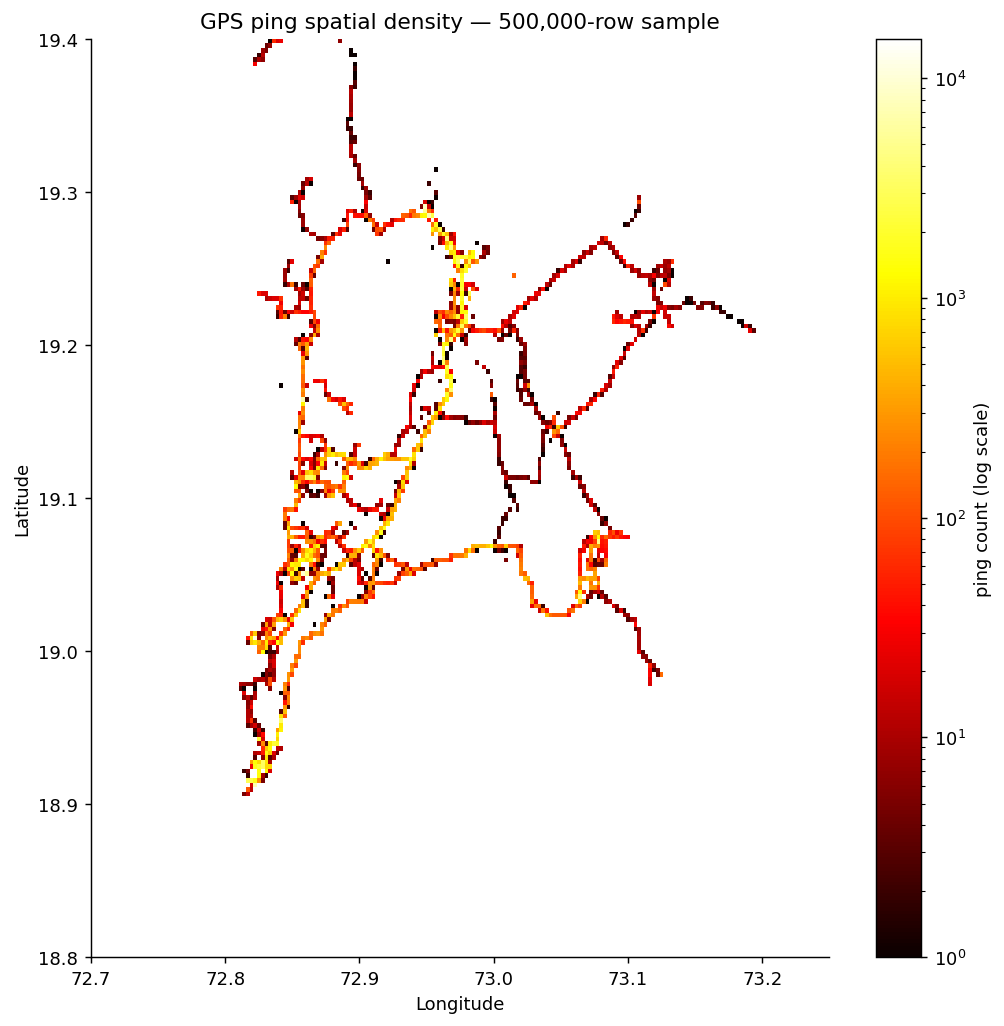

In [15]:
# TIMESTAMP parsing and validity
gps_ts = gps.with_columns([
    pl.col("timestamp").str.to_datetime("%Y-%m-%d %H:%M:%S%.f%#z", strict=False).alias("ts_utc") 
]).with_columns([pl.col("ts_utc").dt.convert_time_zone("Asia/Kolkata").alias("ts_ist")])

n_valid = gps_ts["ts_utc"].is_not_null().sum()
print(f"Valid timestamps : {n_valid:,} / {len(gps_ts):,} ({100*n_valid/len(gps_ts):.2f}%)")

ts_v = gps_ts.filter(pl.col("ts_utc").is_not_null())
print(f"Date range (UTC) : {ts_v['ts_utc'].min()} → {ts_v['ts_utc'].max()}")
print(f"Date range (IST) : {ts_v['ts_ist'].min()} → {ts_v['ts_ist'].max()}")

# SPATIAL coverage of sample
lat = gps["lat"].drop_nulls().to_numpy()
lng = gps["lng"].drop_nulls().to_numpy()

out_bb = np.sum(
    (lat < MUMBAI_BBOX["lat_min"])
    | (lat > MUMBAI_BBOX["lat_max"])
    | (lng < MUMBAI_BBOX["lng_min"])
    | (lng > MUMBAI_BBOX["lng_max"])
)
print(f"Pings outside Mumbai bbox : {out_bb:,} ({100*out_bb/len(lat):.2f}%)")
print(f"Lat range : [{lat.min():.5f}, {lat.max():.5f}]")
print(f"Lng range : [{lng.min():.5f}, {lng.max():.5f}]")

# Extra-bbox pings — are these Pune/Navi Mumbai suburbs or junk?
mask_out = (
    (gps["lat"].to_numpy() < MUMBAI_BBOX["lat_min"])
    | (gps["lat"].to_numpy() > MUMBAI_BBOX["lat_max"])
    | (gps["lng"].to_numpy() < MUMBAI_BBOX["lng_min"])
    | (gps["lng"].to_numpy() > MUMBAI_BBOX["lng_max"])
)
out_df = gps.filter(pl.Series(mask_out)).select(["lat", "lng", "speed", "source"])
print("\nSample of out-of-bbox pings (first 10):")
print(out_df.head(10).to_pandas().to_string())

fig, ax = plt.subplots(figsize=(8, 8))
h = ax.hist2d(
    lng,
    lat,
    bins=200,
    range=[[72.7, 73.25], [18.8, 19.4]],
    cmap="hot",
    norm=matplotlib.colors.LogNorm(),
)
plt.colorbar(h[3], ax=ax, label="ping count (log scale)")
ax.set_title(f"GPS ping spatial density — {N_SAMPLE:,}-row sample")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(FIGURES / "5_spatial_density.png", bbox_inches="tight", dpi=150)
plt.show()

In [16]:
# Coordinate anomaly audit
zero_coord = gps.filter(
    (pl.col("lat") == 0) |
    (pl.col("lng") == 0)
)

print(f"Rows with lat=0 or lng=0 : {len(zero_coord):,} ({100*len(zero_coord)/len(gps):.3f}%)")

if len(zero_coord) > 0:
    print("\nSample zero-coordinate rows:")
    print(zero_coord.select(["lat", "lng", "speed", "source", "vehicle_id"]).head(20).to_pandas().to_string(index=False))

coord_outliers = gps.filter(
    (pl.col("lat") < 18.0) |
    (pl.col("lat") > 20.0) |
    (pl.col("lng") < 72.0) |
    (pl.col("lng") > 74.0)
)

print(f"\nExtreme coordinate outliers : {len(coord_outliers):,}")

if len(coord_outliers) > 0:
    print(coord_outliers.group_by(["lat", "lng"]).len().sort("len", descending=True).head(20).to_pandas().to_string(index=False))

Rows with lat=0 or lng=0 : 1 (0.000%)

Sample zero-coordinate rows:
 lat  lng  speed  source  vehicle_id
 0.0  0.0    NaN       1         677

Extreme coordinate outliers : 19
      lat       lng  len
28.407188 77.057065    5
28.406880 77.058143    5
28.479588 77.034832    2
 0.000000  0.000000    1
28.408040 77.194810    1
28.408200 77.194920    1
28.407280 77.194570    1
28.504860 77.069680    1
28.408210 77.194870    1
28.408050 77.194880    1


### Findings

- The GPS sample contains 14 columns and matches the documented legacy schema.
- `c10` is entirely null and can be removed.
- `c11` contains only three values (`1`, `2`, `4`) but is undocumented.
- `c13` is partially populated (23.1% null) and undocumented.
- `speed` and `bearing` contain 14.8% missing values.
- `deviation_s` has very low missingness (0.1%).
- The sample contains records from 120 unique vehicles.
- Only source values `1` and `2` are present in the sample.
- Several recurring extreme speed values were observed, including `602`, `699.999`, `800`, `1000`, and `1200` km/h.
- These values are unlikely to represent real vehicle speeds and will be investigated during filter design.
- All sampled timestamps were parsed successfully.
- Sampled GPS records span September 2021 to October 2022.
- GPS pings are concentrated within the Mumbai metropolitan region.
- A small number of spatial outliers were identified, including one `(0,0)` coordinate and a few records near Delhi.
- Spatial outliers represent a negligible fraction of the sample.

### Preliminary Decisions

- Drop `c10`.
- Drop `c11`.
- Drop `c13`.
- Retain `speed`, `bearing`, `source`, and `deviation_s` for further analysis.
- Final speed, deviation, and spatial filters will be defined after the GPS audit is completed.

## Section 6 — Filter Impact Analysis

Apply each filter sequentially. Record rows surviving each stage. These percentages directly justify every threshold in `pipeline_params.yaml`.

**Filter order matters:** apply cheap/high-yield filters first.

Step                                      Rows  % of raw  Rows lost
────────────────────────────────────────────────────────────────────
  0_raw                                500,000   100.00%  -       0
  1_valid_timestamp                    500,000   100.00%  -       0
  2_coord_bbox                         497,178    99.44%  -   2,822
  3_valid_source                       497,178    99.44%  -       0
  4_deviation_300s                     496,709    99.34%  -     469
  5_dedup_veh_ts                       495,588    99.12%  -   1,121


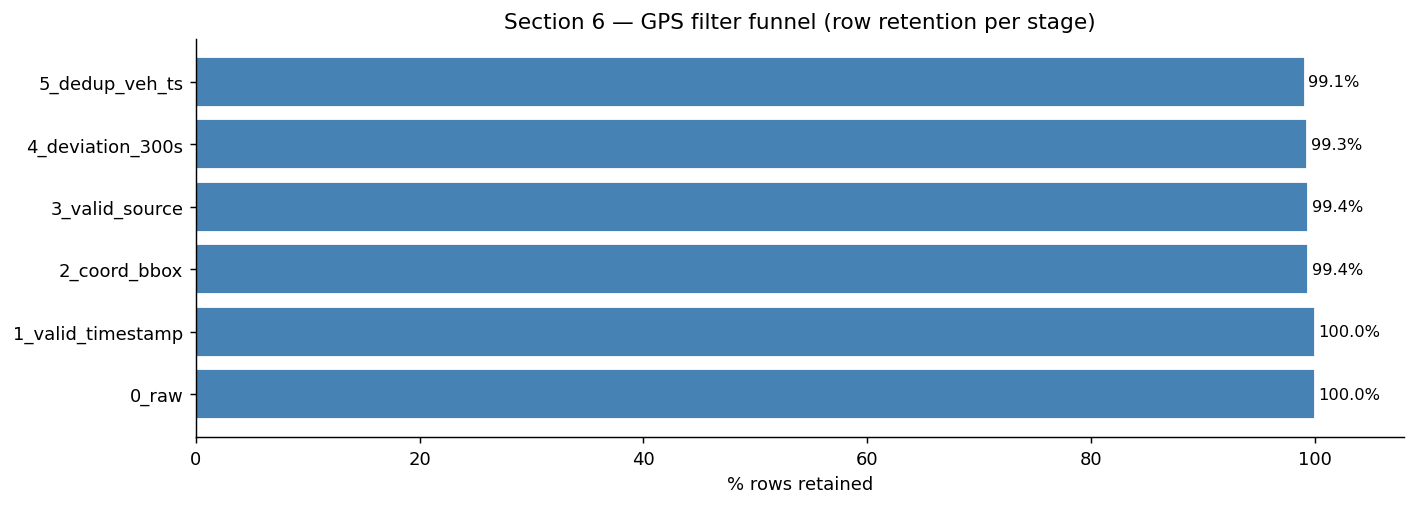

In [17]:
# Build a working dataframe with parsed timestamps and sentinel-nulled speed
gps_work = gps.with_columns(
    [
        pl.col("timestamp")
        .str.to_datetime("%Y-%m-%d %H:%M:%S%.f%#z", strict=False)
        .alias("ts_utc"),
        # NULL out speed sentinels BEFORE numeric filter
        pl.when(pl.col("speed") > 120)
        .then(None)
        .otherwise(pl.col("speed"))
        .alias("speed"),
    ]
).with_columns([pl.col("ts_utc").dt.convert_time_zone("Asia/Kolkata").alias("ts_ist")])

steps = {}
steps["0_raw"] = len(gps_work)

# Filter 1: valid timestamp
f1 = gps_work.filter(pl.col("ts_utc").is_not_null())
steps["1_valid_timestamp"] = len(f1)

# Filter 2: valid coordinates + bbox
f2 = f1.filter(
    pl.col("lat").is_not_null()
    & pl.col("lng").is_not_null()
    & (pl.col("lat") != 0)
    & (pl.col("lng") != 0)
    & pl.col("lat").is_between(MUMBAI_BBOX["lat_min"], MUMBAI_BBOX["lat_max"])
    & pl.col("lng").is_between(MUMBAI_BBOX["lng_min"], MUMBAI_BBOX["lng_max"])
)
steps["2_coord_bbox"] = len(f2)

# Filter 3: valid source
f3 = f2.filter(pl.col("source").is_in([1, 2, 4]))
steps["3_valid_source"] = len(f3)

# Filter 4: deviation filter
f4 = f3.filter(pl.col("deviation_s").is_null() | (pl.col("deviation_s").abs() <= 300))
steps["4_deviation_300s"] = len(f4)

# Filter 5: deduplicate same vehicle × timestamp
f5 = f4.unique(subset=["vehicle_id", "ts_utc"], keep="first")
steps["5_dedup_veh_ts"] = len(f5)

# Summary table
print(f"{'Step':<35} {'Rows':>10} {'% of raw':>9} {'Rows lost':>10}")
print("─" * 68)
prev = steps["0_raw"]
for step, n in steps.items():
    pct = 100 * n / steps["0_raw"]
    lost = prev - n
    print(f"  {step:<33} {n:>10,} {pct:>8.2f}%  -{lost:>8,}")
    prev = n

fig, ax = plt.subplots(figsize=(11, 4))
labels = list(steps.keys())
values = [100 * v / steps["0_raw"] for v in steps.values()]
bars = ax.barh(labels, values, color="steelblue", edgecolor="white")
ax.set_xlabel("% rows retained")
ax.set_xlim(0, 108)
ax.set_title("Section 6 — GPS filter funnel (row retention per stage)")
for bar, val in zip(bars, values):
    ax.text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig(FIGURES / "6_filter_funnel.png", bbox_inches="tight")
plt.show()

### Findings

- Timestamp quality is excellent; all sampled records contain valid GPS timestamps.
- Coordinate and Mumbai bounding-box filtering removed 2,822 records (0.56%), primarily due to a small number of geographic outliers identified earlier.
- No unexpected source values were observed in the sample.
- The deviation filter (`|deviation_s| ≤ 300s`) removed only 469 records (0.09%), indicating good agreement between GPS and database timestamps.
- Deduplication on `(vehicle_id, timestamp)` removed 1,121 records (0.22%), suggesting a small number of duplicate GPS entries.
- Overall retention after all quality filters was **99.12%** (495,588 / 500,000 rows), indicating that the raw GPS data is generally clean and requires only minimal filtering.

## Section 7 — Temporal Coverage Analysis

We use **Polars lazy streaming** over all 3 GPS files to determine:
1. The actual GPS date range (defines the real study window, NOT trips.csv dates)
2. Daily and hourly ping volume (detects gaps, holidays, system outages)
3. Monthly distribution (confirms monsoon season representation)

**No full file is loaded into RAM. Only aggregated counts are collected.**

In [3]:
from datetime import date

print("Scanning all 3 GPS files lazily for temporal coverage...")

frames = []
for gps_file in GPS_FILES:
    if not gps_file.exists():
        print(f"  {gps_file.name} not found — skip")
        continue
    lf = (
        pl.scan_csv(
            gps_file,
            has_header=False,
            new_columns=LEGACY_COLS,
            schema_overrides=LEGACY_DTYPES,
            ignore_errors=True,
            infer_schema_length=0,
            null_values=["", "NULL", "null"],
            truncate_ragged_lines=True,
        )
        .with_columns(
            [
                pl.col("timestamp")
                .str.to_datetime("%Y-%m-%d %H:%M:%S%.f%#z", strict=False)
                .alias("ts_utc")
            ]
        )
        .filter(
            pl.col("ts_utc").is_not_null()
            & (
                pl.col("ts_utc").dt.date() >= pl.lit(date(2021, 9, 1))
            )
        )
        .with_columns(
            [pl.col("ts_utc").dt.convert_time_zone("Asia/Kolkata").alias("ts_ist")]
        )
        .with_columns(
            [
                pl.col("ts_ist").dt.date().alias("ride_date"),
                pl.col("ts_ist").dt.hour().alias("hour"),
                pl.col("ts_ist").dt.month().alias("month"),
                pl.col("ts_ist").dt.weekday().alias("dow"),
            ]
        )
    )
    # Aggregate per file to keep memory minimal
    agg = lf.group_by(["ride_date","hour","month","dow"]).agg([
        pl.len().alias("n_pings"),
        pl.col("vehicle_id").n_unique().alias("n_vehicles"),
    ]).collect(engine="streaming")
    frames.append(agg)
    print(f"  {gps_file.name[:55]} — {len(agg):,} date-hour groups")

if frames:
    full_agg = pl.concat(frames).group_by(["ride_date","hour","month","dow"]).agg([
        pl.col("n_pings").sum(),
        pl.col("n_vehicles").sum(),
    ])
    # Daily totals
    pings_per_day = (
        full_agg.group_by("ride_date").agg(pl.col("n_pings").sum())
        .sort("ride_date").to_pandas()
    )
    pings_per_day["ride_date"] = pd.to_datetime(pings_per_day["ride_date"])

    print("\nTEMPORAL COVERAGE SUMMARY —")
    print(f"Date range: {pings_per_day['ride_date'].min().date()} → {pings_per_day['ride_date'].max().date()}")
    print(f"Total days with pings: {len(pings_per_day):,}")
    print(f"Total pings (all files): {pings_per_day['n_pings'].sum():,.0f}")
else:
    print("No GPS files found — cannot compute temporal coverage.")
    pings_per_day = pd.DataFrame(columns=["ride_date","n_pings"])

Scanning all 3 GPS files lazily for temporal coverage...
  before_2022-10-22_698096e5f4994518a37a0b9c59bb9756 — 3,758 date-hour groups
  before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part — 3,467 date-hour groups
  before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part — 2,794 date-hour groups

TEMPORAL COVERAGE SUMMARY —
Date range: 2021-09-01 → 2022-10-22
Total days with pings: 417
Total pings (all files): 165,019,149


In [3]:
vehicle_sets = {}

for f in GPS_FILES:
    print(f.name)

    vids = (
        pl.scan_csv(
            f,
            has_header=False,
            new_columns=LEGACY_COLS,
            schema_overrides=LEGACY_DTYPES,
            ignore_errors=True,
            infer_schema_length=0,
            truncate_ragged_lines=True,
        )
        .select(pl.col("vehicle_id").unique())
        .collect(engine="streaming")["vehicle_id"]
        .to_list()
    )

    vehicle_sets[f.name] = set(vids)

    print("vehicles:", len(vehicle_sets[f.name]))


before_2022-10-22_698096e5f4994518a37a0b9c59bb9756
vehicles: 189
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part2
vehicles: 232
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part3
vehicles: 250


In [4]:
from itertools import combinations

for a, b in combinations(vehicle_sets.keys(), 2):
    overlap = len(vehicle_sets[a] & vehicle_sets[b])

    print()
    print(a)
    print(b)
    print("shared vehicles:", overlap)



before_2022-10-22_698096e5f4994518a37a0b9c59bb9756
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part2
shared vehicles: 180

before_2022-10-22_698096e5f4994518a37a0b9c59bb9756
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part3
shared vehicles: 178

before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part2
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part3
shared vehicles: 227


In [5]:
for f in GPS_FILES:
    print("\n", f.name)

    stats = (
        pl.scan_csv(
            f,
            has_header=False,
            new_columns=LEGACY_COLS,
            schema_overrides=LEGACY_DTYPES,
            ignore_errors=True,
            infer_schema_length=0,
            truncate_ragged_lines=True,
        )
        .with_columns(
            pl.col("timestamp")
            .str.to_datetime("%Y-%m-%d %H:%M:%S%.f%#z", strict=False)
            .alias("ts")
        )
        .select(
            [
                pl.min("ts").alias("min_ts"),
                pl.max("ts").alias("max_ts"),
                pl.len().alias("rows"),
            ]
        )
        .collect(engine="streaming")
    )

    print(stats)



 before_2022-10-22_698096e5f4994518a37a0b9c59bb9756
shape: (1, 3)
┌─────────────────────────┬─────────────────────────┬──────────┐
│ min_ts                  ┆ max_ts                  ┆ rows     │
│ ---                     ┆ ---                     ┆ ---      │
│ datetime[μs, UTC]       ┆ datetime[μs, UTC]       ┆ u32      │
╞═════════════════════════╪═════════════════════════╪══════════╡
│ 1970-01-01 00:00:20 UTC ┆ 2022-10-01 06:39:51 UTC ┆ 57784583 │
└─────────────────────────┴─────────────────────────┴──────────┘

 before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part2
shape: (1, 3)
┌─────────────────────────┬─────────────────────────────┬──────────┐
│ min_ts                  ┆ max_ts                      ┆ rows     │
│ ---                     ┆ ---                         ┆ ---      │
│ datetime[μs, UTC]       ┆ datetime[μs, UTC]           ┆ u32      │
╞═════════════════════════╪═════════════════════════════╪══════════╡
│ 2021-11-30 13:34:49 UTC ┆ 2022-09-29 11:59:43.017 UTC ┆ 58

In [6]:
vehicle_file_presence = []

for f in GPS_FILES:
    tmp = (
        pl.scan_csv(
            f,
            has_header=False,
            new_columns=LEGACY_COLS,
            schema_overrides=LEGACY_DTYPES,
            ignore_errors=True,
            infer_schema_length=0,
            truncate_ragged_lines=True,
        )
        .select(
            [
                pl.col("vehicle_id").unique(),
                pl.lit(f.name).alias("file"),
            ]
        )
        .collect(engine="streaming")
    )

    vehicle_file_presence.append(tmp)

presence = pl.concat(vehicle_file_presence)

presence_summary = presence.group_by("vehicle_id").agg(pl.len().alias("n_files"))

presence_summary["n_files"].value_counts().sort("n_files")


n_files,count
u32,u32
1,26
2,60
3,175


In [4]:
for f in GPS_FILES:
    rows = (
        pl.scan_csv(
            f,
            has_header=False,
            new_columns=LEGACY_COLS,
            schema_overrides=LEGACY_DTYPES,
            ignore_errors=True,
            infer_schema_length=0,
            truncate_ragged_lines=True,
        )
        .select((pl.col("vehicle_id") % 8).alias("bucket"))
        .group_by("bucket")
        .agg(pl.len().alias("rows"))
        .collect(engine="streaming")
    )

    print(f.name)
    print(rows)


before_2022-10-22_698096e5f4994518a37a0b9c59bb9756
shape: (8, 2)
┌────────┬─────────┐
│ bucket ┆ rows    │
│ ---    ┆ ---     │
│ i64    ┆ u32     │
╞════════╪═════════╡
│ 6      ┆ 6468475 │
│ 3      ┆ 6853782 │
│ 4      ┆ 7831431 │
│ 0      ┆ 6850381 │
│ 2      ┆ 6134560 │
│ 1      ┆ 6839584 │
│ 7      ┆ 9816339 │
│ 5      ┆ 6990031 │
└────────┴─────────┘
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part2
shape: (8, 2)
┌────────┬─────────┐
│ bucket ┆ rows    │
│ ---    ┆ ---     │
│ i64    ┆ u32     │
╞════════╪═════════╡
│ 1      ┆ 7519344 │
│ 3      ┆ 7406351 │
│ 6      ┆ 6793978 │
│ 2      ┆ 7111720 │
│ 5      ┆ 6831582 │
│ 0      ┆ 6129944 │
│ 7      ┆ 8664055 │
│ 4      ┆ 7771410 │
└────────┴─────────┘
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part3
shape: (8, 2)
┌────────┬─────────┐
│ bucket ┆ rows    │
│ ---    ┆ ---     │
│ i64    ┆ u32     │
╞════════╪═════════╡
│ 2      ┆ 5071814 │
│ 1      ┆ 7089399 │
│ 6      ┆ 5932155 │
│ 3      ┆ 5929701 │
│ 4      ┆ 67705

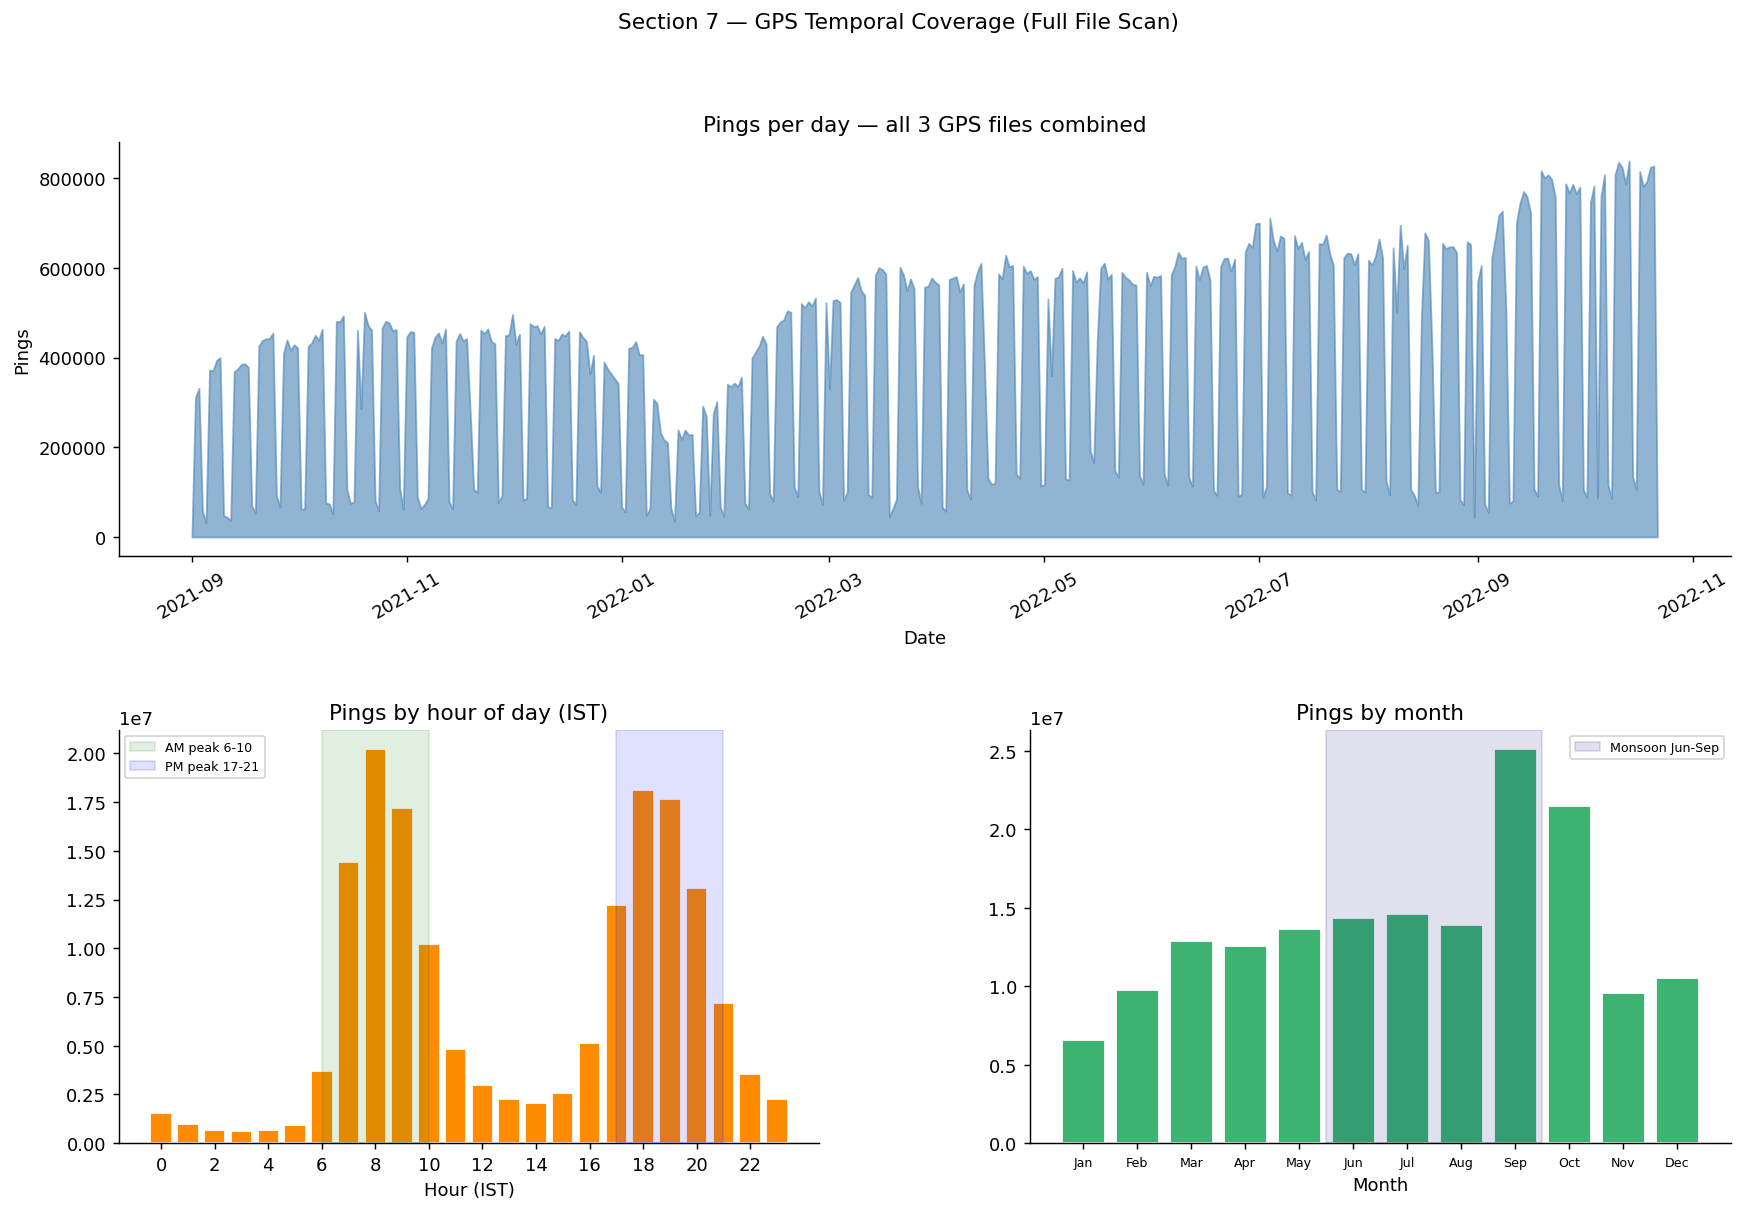

In [19]:
if len(pings_per_day) > 0:
    # Hourly profile
    pings_per_hour = (
        full_agg.group_by("hour").agg(pl.col("n_pings").sum())
        .sort("hour").to_pandas()
    )
    # Monthly distribution
    pings_per_month = (
        full_agg.group_by("month").agg(pl.col("n_pings").sum())
        .sort("month").to_pandas()
    )
    # Day-of-week
    pings_per_dow = (
        full_agg.group_by("dow").agg(pl.col("n_pings").sum())
        .sort("dow").to_pandas()
    )

    fig = plt.figure(figsize=(16, 10))
    from matplotlib.gridspec import GridSpec
    gs = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.3)

    # 1) Daily timeline
    ax1 = fig.add_subplot(gs[0, :])  # full width
    ax1.fill_between(pings_per_day["ride_date"], pings_per_day["n_pings"], alpha=0.6, color="steelblue")
    ax1.set_title("Pings per day — all 3 GPS files combined")
    ax1.set_xlabel("Date"); ax1.set_ylabel("Pings")
    ax1.tick_params(axis="x", rotation=30)
    # Annotate any large gaps (> 7 days with zero pings)
    dates_sorted = pings_per_day.sort_values("ride_date")
    gaps = dates_sorted["ride_date"].diff().dt.days
    big_gaps = gaps[gaps > 7]
    for idx in big_gaps.index:
        d = dates_sorted["ride_date"].iloc[idx]
        ax1.axvline(d, color="red", alpha=0.5, lw=1)
    if len(big_gaps) > 0:
        ax1.text(0.01, 0.92, f"Red lines = data gaps > 7 days ({len(big_gaps)} found)", transform=ax1.transAxes, fontsize=8, color="red")

    # 2) Hourly profile (IST)
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.bar(pings_per_hour["hour"], pings_per_hour["n_pings"],
            color="darkorange", edgecolor="white")
    ax2.set_title("Pings by hour of day (IST)")
    ax2.set_xlabel("Hour (IST)")
    ax2.set_xticks(range(0, 24, 2))
    # Shade peak windows
    ax2.axvspan(6, 10, alpha=0.12, color="green", label="AM peak 6-10")
    ax2.axvspan(17, 21, alpha=0.12, color="blue", label="PM peak 17-21")
    ax2.legend(fontsize=7)

    # 3) Monthly
    ax3 = fig.add_subplot(gs[1, 1])
    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    ax3.bar(pings_per_month["month"], pings_per_month["n_pings"], color="mediumseagreen", edgecolor="white")
    ax3.set_title("Pings by month")
    ax3.set_xlabel("Month")
    ax3.set_xticks(range(1, 13))
    ax3.set_xticklabels(month_names, fontsize=7)
    # Shade monsoon (Jun-Sep)
    ax3.axvspan(5.5, 9.5, alpha=0.12, color="navy", label="Monsoon Jun-Sep")
    ax3.legend(fontsize=7)

    plt.suptitle("Section 7 — GPS Temporal Coverage (Full File Scan)", fontsize=12)
    plt.savefig(FIGURES / "7_temporal_coverage.png", bbox_inches="tight")
    plt.show()

### Findings

- GPS data spans **1 September 2021 to 22 October 2022**, covering **417 active days** and **165.0 million GPS pings**.
- Temporal coverage is largely continuous across the study period, with no major prolonged missing-data intervals after removal of obvious timestamp artifacts.
- Daily GPS volume increases over time, from roughly **0.35–0.50 million pings/day** in late 2021 to **0.70–0.85 million pings/day** by late 2022.
- A noticeable reduction in GPS activity is observed around **January 2022**, suggesting a temporary operational slowdown or reduced reporting period.
- Hourly activity exhibits a clear **bimodal commuter pattern**, with peaks during **morning (7–9 AM)** and **evening (6–8 PM)** periods.
- Monthly volumes are highest during **September–October 2022**, although direct month-to-month comparisons should be interpreted cautiously due to varying month lengths and partial-month coverage at dataset boundaries.

## Section 8 — Segmentation Threshold Analysis

In [20]:
# 8a. Gap distribution
f5_sorted = f5.sort(["vehicle_id", "ts_ist"])

f5_gaps = (
    f5_sorted.with_columns(
        [pl.col("ts_ist").shift(1).over("vehicle_id").alias("_ts_prev")]
    )
    .with_columns(
        [
            (
                (pl.col("ts_ist").cast(pl.Int64) - pl.col("_ts_prev").cast(pl.Int64))
                / 1e6
                / 60.0
            ).alias("gap_min")
        ]
    )
    .filter(pl.col("gap_min").is_not_null() & (pl.col("gap_min") >= 0))
)

gap_arr = f5_gaps["gap_min"].to_numpy()
gap_valid = gap_arr[~np.isnan(gap_arr)]

print(f"Inter-ping gaps computed: {len(gap_valid):,} transitions")

print("\nGap distribution percentiles:")
for p in [50, 75, 90, 95, 99, 99.5]:
    print(f"  p{p:5.1f}: {np.percentile(gap_valid, p):.2f} min")

print("\nNew-segment counts by threshold:")
for thresh in [5, 10, 15, 20, 25, 30, 45, 60]:
    n_breaks = (gap_valid > thresh).sum()
    pct = 100 * n_breaks / len(gap_valid)
    avg_seg_pings = len(gap_valid) / max(n_breaks, 1)

    print(
        f"  gap > {thresh:3d} min : "
        f"{n_breaks:5,} breaks "
        f"({pct:.3f}% of transitions)  "
        f"avg ~{avg_seg_pings:.0f} pings/segment"
    )

Inter-ping gaps computed: 495,473 transitions

Gap distribution percentiles:
  p 50.0: 0.10 min
  p 75.0: 0.14 min
  p 90.0: 0.17 min
  p 95.0: 0.17 min
  p 99.0: 0.82 min
  p 99.5: 9.00 min

New-segment counts by threshold:
  gap >   5 min : 3,319 breaks (0.670% of transitions)  avg ~149 pings/segment
  gap >  10 min :   686 breaks (0.138% of transitions)  avg ~722 pings/segment
  gap >  15 min :   561 breaks (0.113% of transitions)  avg ~883 pings/segment
  gap >  20 min :   494 breaks (0.100% of transitions)  avg ~1003 pings/segment
  gap >  25 min :   454 breaks (0.092% of transitions)  avg ~1091 pings/segment
  gap >  30 min :   423 breaks (0.085% of transitions)  avg ~1171 pings/segment
  gap >  45 min :   375 breaks (0.076% of transitions)  avg ~1321 pings/segment
  gap >  60 min :   349 breaks (0.070% of transitions)  avg ~1420 pings/segment


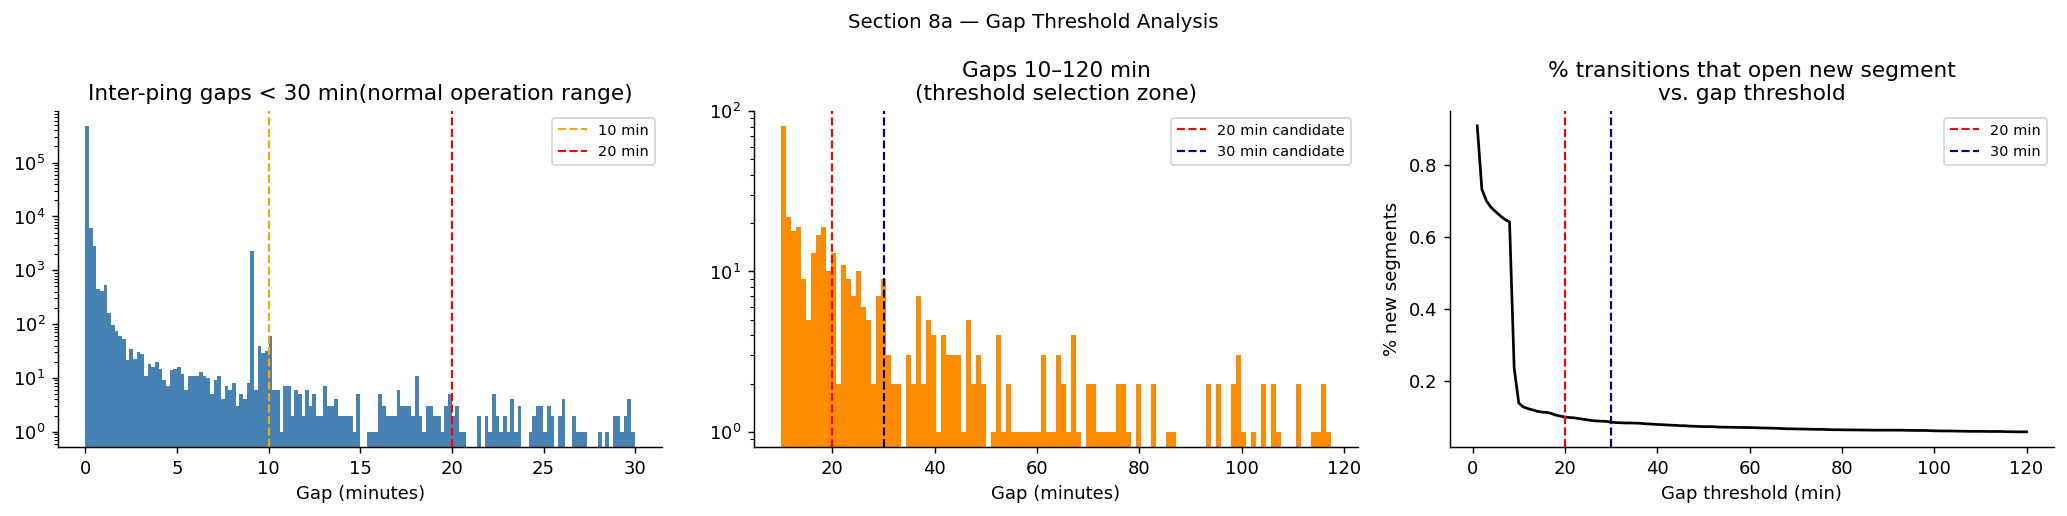

In [21]:
# Gap distribution plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: < 30 min (where the 'within-trip' gaps live)
axes[0].hist(gap_valid[gap_valid < 30], bins=150, color="steelblue", edgecolor="none")
for thresh, c in [(10,"orange"), (20,"red")]:
    axes[0].axvline(thresh, color=c, ls="--", lw=1.2, label=f"{thresh} min")
    axes[0].set_title("Inter-ping gaps < 30 min(normal operation range)")
    axes[0].set_xlabel("Gap (minutes)"); axes[0].legend(fontsize=8); axes[0].set_yscale("log")

# Plot 2: 20-120 min (the threshold selection range)
axes[1].hist(gap_valid[(gap_valid >= 10) & (gap_valid < 120)],
             bins=110, color="darkorange", edgecolor="none")
for thresh, c in [(20,"red"), (30,"navy")]:
    axes[1].axvline(thresh, color=c, ls="--", lw=1.2, label=f"{thresh} min candidate")
axes[1].set_title("Gaps 10–120 min\n(threshold selection zone)")
axes[1].set_xlabel("Gap (minutes)")
axes[1].legend(fontsize=8)
axes[1].set_yscale("log")

# Plot 3: Cumulative % of transitions that become new segments
thresholds = np.arange(1, 121, 1)
pct_breaks = [100 * (gap_valid > t).sum() / len(gap_valid) for t in thresholds]
axes[2].plot(thresholds, pct_breaks, "k-", lw=1.5)
for thresh, c, label in [(20,"red","20 min"), (30,"navy","30 min")]:
    axes[2].axvline(thresh, color=c, ls="--", lw=1.2, label=label)
axes[2].set_title("% transitions that open new segment\nvs. gap threshold")
axes[2].set_xlabel("Gap threshold (min)")
axes[2].set_ylabel("% new segments")
axes[2].legend(fontsize=8)

plt.suptitle("Section 8a — Gap Threshold Analysis", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "8a_gap_threshold.png", bbox_inches="tight")
plt.show()

In [22]:
# 8b. Segmentation quality by gap threshold
results_by_thresh = {}

for GAP_TH in [15, 20, 25, 30]:

    f5_seg = (
        f5_sorted.with_columns(
            [pl.col("ts_ist").shift(1).over("vehicle_id").alias("_ts_prev")]
        )
        .with_columns(
            [
                pl.when(pl.col("_ts_prev").is_null())
                .then(1)
                .otherwise(
                    (
                        (
                            (
                                pl.col("ts_ist").cast(pl.Int64)
                                - pl.col("_ts_prev").cast(pl.Int64)
                            )
                            / 1e6
                            / 60.0
                        )
                        > GAP_TH
                    ).cast(pl.Int32)
                )
                .alias("is_new")
            ]
        )
        .with_columns(
            [pl.col("is_new").cum_sum().over("vehicle_id").alias("segment_id")]
        )
    )

    seg_stats = (
        f5_seg.group_by(["vehicle_id", "segment_id"])
        .agg(
            [
                pl.len().alias("n_pings"),
                (
                    (
                        pl.col("ts_ist").max().cast(pl.Int64)
                        - pl.col("ts_ist").min().cast(pl.Int64)
                    )
                    / 1e6
                    / 60.0
                ).alias("dur_min"),
            ]
        )
        .to_pandas()
    )

    n_segs = len(seg_stats)
    n_micro = (seg_stats["n_pings"] < 5).sum()
    n_short = (seg_stats["dur_min"] < 5).sum()

    results_by_thresh[GAP_TH] = {
        "n_segments": n_segs,
        "median_pings": seg_stats["n_pings"].median(),
        "median_dur": seg_stats["dur_min"].median(),
        "n_micro_lt5ping": n_micro,
        "n_short_lt5min": n_short,
        "pct_usable": 100 * (1 - max(n_micro, n_short) / n_segs),
    }

print("Segmentation comparison across gap thresholds:\n")

print(
    f"{'Thresh':>7} {'N segs':>8} {'Med pings':>10} "
    f"{'Med dur':>9} {'Micro<5p':>9} {'Short<5m':>9} {'% usable':>9}"
)

print("─" * 72)

for thresh, r in results_by_thresh.items():
    print(
        f"{thresh:>7} "
        f"{r['n_segments']:>8,} "
        f"{r['median_pings']:>10.0f} "
        f"{r['median_dur']:>8.1f} "
        f"{r['n_micro_lt5ping']:>9,} "
        f"{r['n_short_lt5min']:>9,} "
        f"{r['pct_usable']:>8.1f}%"
    )

GAP_TH_CHOSEN = 20

f5_seg = (
    f5_sorted.with_columns(
        [pl.col("ts_ist").shift(1).over("vehicle_id").alias("_ts_prev")]
    )
    .with_columns(
        [
            pl.when(pl.col("_ts_prev").is_null())
            .then(1)
            .otherwise(
                (
                    (
                        (
                            pl.col("ts_ist").cast(pl.Int64)
                            - pl.col("_ts_prev").cast(pl.Int64)
                        )
                        / 1e6
                        / 60.0
                    )
                    > GAP_TH_CHOSEN
                ).cast(pl.Int32)
            )
            .alias("is_new")
        ]
    )
    .with_columns([pl.col("is_new").cum_sum().over("vehicle_id").alias("segment_id")])
)

seg_stats_chosen = (
    f5_seg.group_by(["vehicle_id", "segment_id"])
    .agg(
        [
            pl.len().alias("n_pings"),
            (
                (
                    pl.col("ts_ist").max().cast(pl.Int64)
                    - pl.col("ts_ist").min().cast(pl.Int64)
                )
                / 1e6
                / 60.0
            ).alias("dur_min"),
        ]
    )
    .to_pandas()
)

print(f"\nChosen threshold = {GAP_TH_CHOSEN} min")

for col, label in [
    ("n_pings", "Pings"),
    ("dur_min", "Duration (min)"),
]:
    print(f"\n{label}")
    for p in [10, 25, 50, 75, 90, 95]:
        print(f"  p{p:2d}: {np.percentile(seg_stats_chosen[col], p):.1f}")

Segmentation comparison across gap thresholds:

 Thresh   N segs  Med pings   Med dur  Micro<5p  Short<5m  % usable
────────────────────────────────────────────────────────────────────────
     15      676        196     36.0       125       188     72.2%
     20      609        283     43.7       110       158     74.1%
     25      569        391     65.8       102       138     75.7%
     30      538        464     87.6        98       127     76.4%

Chosen threshold = 20 min

Pings
  p10: 2.0
  p25: 10.0
  p50: 283.0
  p75: 1381.0
  p90: 1941.0
  p95: 2660.2

Duration (min)
  p10: 0.1
  p25: 4.1
  p50: 43.7
  p75: 176.4
  p90: 251.6
  p95: 390.3


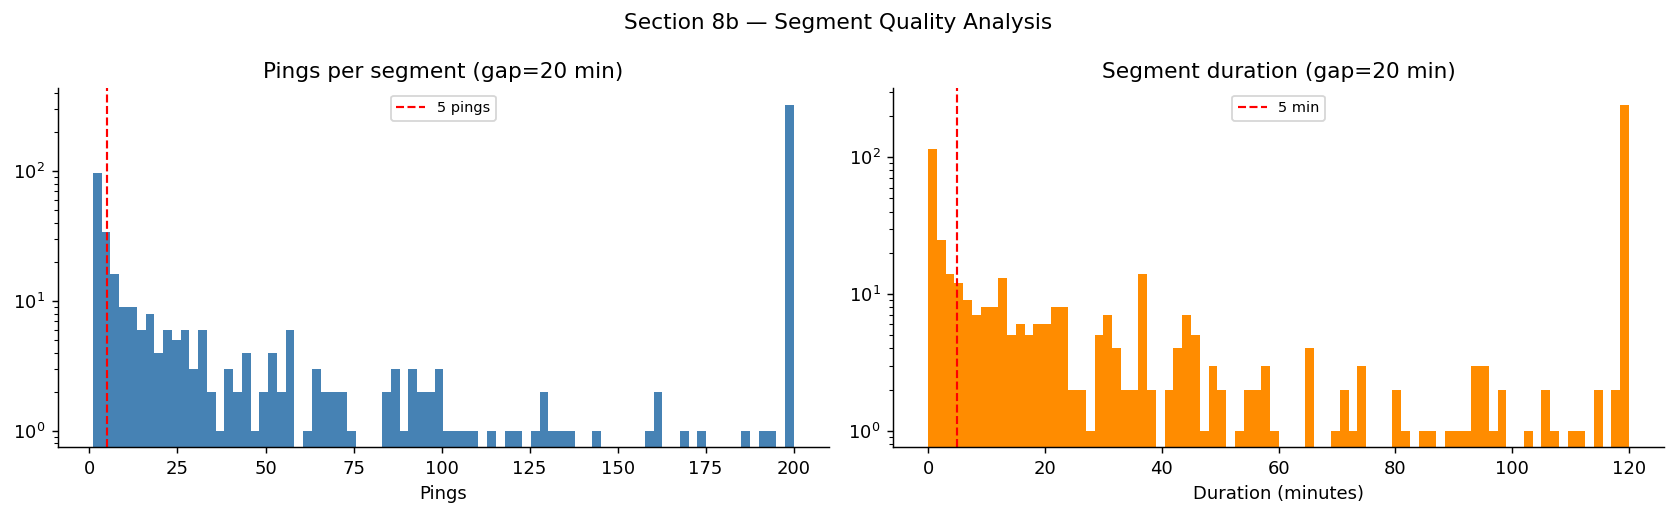

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(
    seg_stats_chosen["n_pings"].clip(upper=200),
    bins=80,
    color="steelblue",
    edgecolor="none",
)

axes[0].axvline(
    5,
    color="red",
    ls="--",
    lw=1.2,
    label="5 pings",
)

axes[0].set_title(f"Pings per segment (gap={GAP_TH_CHOSEN} min)")
axes[0].set_xlabel("Pings")
axes[0].set_yscale("log")
axes[0].legend(fontsize=8)

axes[1].hist(
    seg_stats_chosen["dur_min"].clip(upper=120),
    bins=80,
    color="darkorange",
    edgecolor="none",
)

axes[1].axvline(
    5,
    color="red",
    ls="--",
    lw=1.2,
    label="5 min",
)

axes[1].set_title(f"Segment duration (gap={GAP_TH_CHOSEN} min)")
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_yscale("log")
axes[1].legend(fontsize=8)

plt.suptitle("Section 8b — Segment Quality Analysis")
plt.tight_layout()
plt.savefig(
    FIGURES / "8b_segment_quality.png",
    bbox_inches="tight",
)
plt.show()

In [27]:
from pathlib import Path
from sklearn.neighbors import BallTree
import pandas as pd
import numpy as np

PROCESSED = Path("../data/processed")

stops_clean = pd.read_csv(PROCESSED / "stops_clean.csv")

# 8c. Stop snap distance analysis
stops_valid = stops_clean.dropna(subset=["lat", "lng"]).copy()

# Exclude any remaining invalid coordinates before BallTree construction
stops_valid = stops_valid[
    stops_valid["lat"].between(6, 38) & stops_valid["lng"].between(68, 98)
].reset_index(drop=True)

tree = BallTree(np.radians(stops_valid[["lat", "lng"]].values), metric="haversine")
stop_ids_np = stops_valid["stop_id"].values

lats = f5["lat"].to_numpy()
lngs = f5["lng"].to_numpy()

q = np.radians(np.column_stack([lats, lngs]))
dist_rad, idx = tree.query(q, k=1)
d_m = dist_rad.flatten() * 6371.0 * 1000.0

print(f"Nearest-stop distance statistics ({len(d_m):,} pings):")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:2d}: {np.percentile(d_m, p):.0f} m")

print("\nCandidate snap radii:")
for radius in [100, 200, 300, 500, 1000]:
    pct = 100 * (d_m <= radius).mean()
    print(f"  <= {radius:3d}m -> {pct:5.1f}% coverage")

Nearest-stop distance statistics (495,588 pings):
  p10: 19 m
  p25: 42 m
  p50: 112 m
  p75: 243 m
  p90: 489 m
  p95: 748 m
  p99: 1242 m

Candidate snap radii:
  <= 100m ->  46.8% coverage
  <= 200m ->  68.2% coverage
  <= 300m ->  81.6% coverage
  <= 500m ->  90.4% coverage
  <= 1000m ->  98.3% coverage


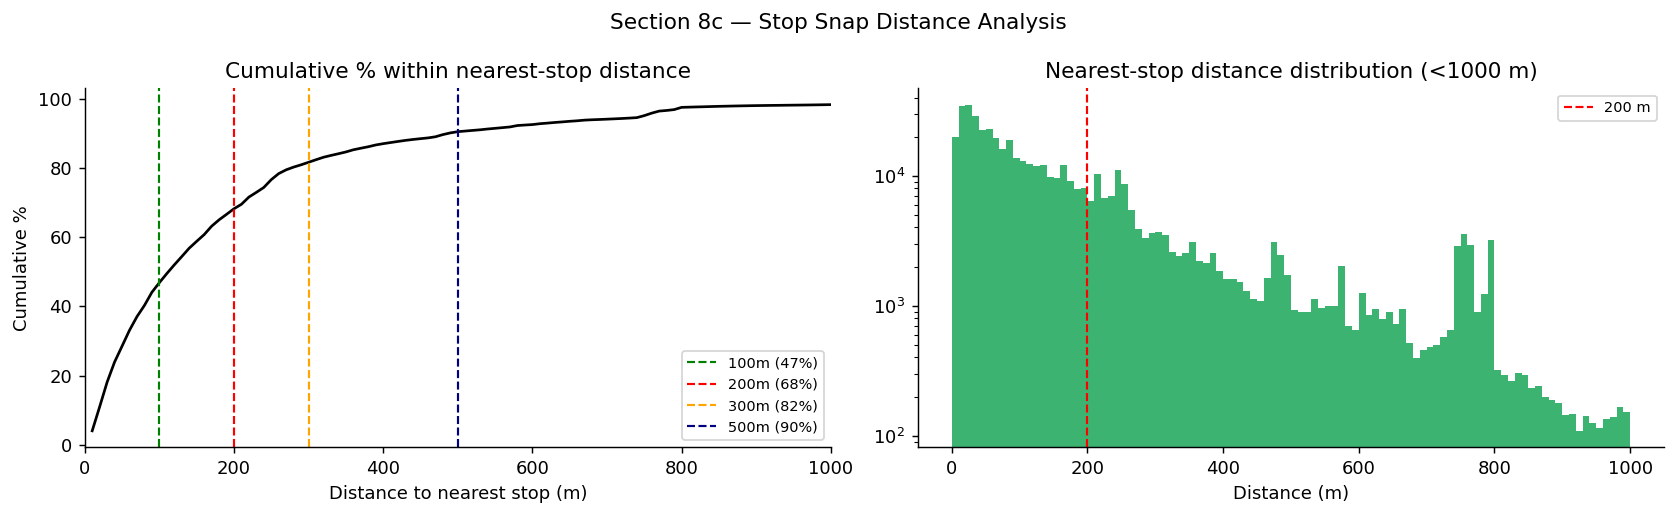

In [28]:
# Snap distance plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# CDF
bins = np.arange(0, 1001, 10)
hist, edges = np.histogram(d_m, bins=bins)
cdf = np.cumsum(hist) / len(d_m)

axes[0].plot(edges[1:], 100 * cdf, "k-", lw=1.5)

for thresh, c in [(100, "green"), (200, "red"), (300, "orange"), (500, "navy")]:
    pct = 100 * (d_m <= thresh).mean()
    axes[0].axvline(thresh, color=c, ls="--", lw=1.2, label=f"{thresh}m ({pct:.0f}%)")

axes[0].set_title("Cumulative % within nearest-stop distance")
axes[0].set_xlabel("Distance to nearest stop (m)")
axes[0].set_ylabel("Cumulative %")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 1000)

# Histogram
axes[1].hist(d_m[d_m < 1000], bins=100, color="mediumseagreen", edgecolor="none")
axes[1].axvline(200, color="red", ls="--", lw=1.2, label="200 m")
axes[1].set_title("Nearest-stop distance distribution (<1000 m)")
axes[1].set_xlabel("Distance (m)")
axes[1].legend(fontsize=8)
axes[1].set_yscale("log")

plt.suptitle("Section 8c — Stop Snap Distance Analysis")
plt.tight_layout()
plt.savefig(FIGURES / "8c_snap_distance.png", bbox_inches="tight")
plt.show()

Snap rate by stop_category (snapped pings only, threshold 300m):
  Morning   : 80.1% within 300m (n=315,443)
  Evening   : 84.3% within 300m (n=180,145)


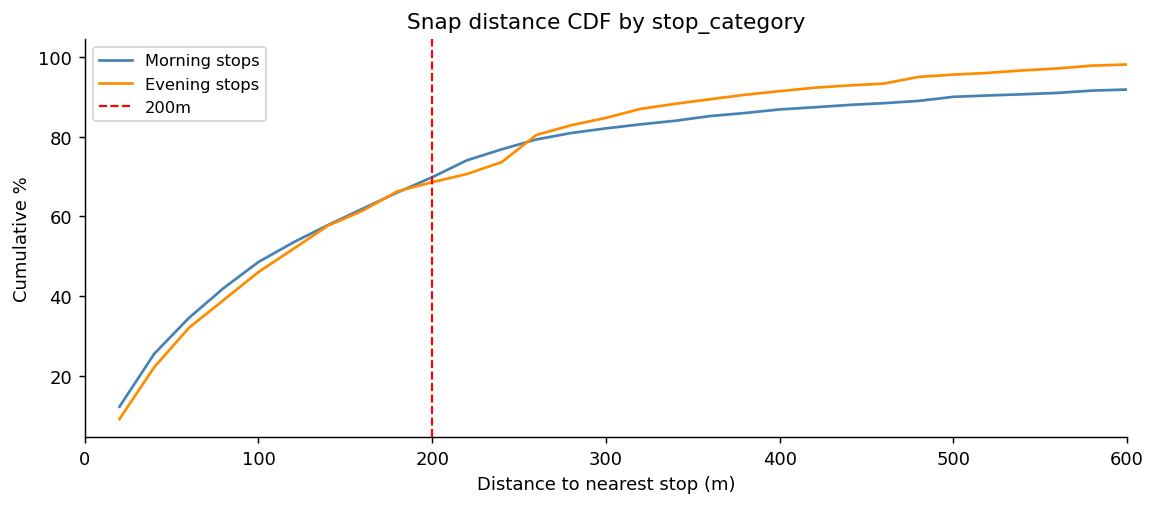

In [30]:
# 8d. Stop proximity distribution by stop_category
# Do Morning vs Evening stops have different snap distances?

SNAP_RADIUS = 300  # or 200 for stricter threshold

snapped_stop_ids = stop_ids_np[idx.flatten()]
d_m_series = pd.Series(d_m)
snap_df = pd.DataFrame(
    {
        "snap_distance_m": d_m,
        "snapped_stop_id": snapped_stop_ids,
        "within_radius": d_m <= SNAP_RADIUS,
    }
)
snap_df = snap_df.merge(
    stops_valid[["stop_id", "stop_category"]],
    left_on="snapped_stop_id",
    right_on="stop_id",
    how="left",
)

print(f"Snap rate by stop_category (snapped pings only, threshold {SNAP_RADIUS}m):")
for cat in snap_df["stop_category"].dropna().unique():
    subset = snap_df[snap_df["stop_category"] == cat]
    rate = 100 * subset["within_radius"].mean()
    print(f"  {cat:10s}: {rate:.1f}% within {SNAP_RADIUS}m (n={len(subset):,})")

fig, ax = plt.subplots(figsize=(9, 4))
for cat, col in [("Morning", "steelblue"), ("Evening", "darkorange")]:
    sub = snap_df[snap_df["stop_category"] == cat]["snap_distance_m"]
    sub = sub[sub < 1000]
    bins_ = np.arange(0, 1001, 20)
    h_, e_ = np.histogram(sub, bins=bins_)
    cdf_ = np.cumsum(h_) / len(sub)
    ax.plot(e_[1:], 100 * cdf_, color=col, lw=1.5, label=f"{cat} stops")
ax.axvline(200, color="red", ls="--", lw=1.2, label="200m")
ax.set_title("Snap distance CDF by stop_category")
ax.set_xlabel("Distance to nearest stop (m)")
ax.set_ylabel("Cumulative %")
ax.legend(fontsize=9)
ax.set_xlim(0, 600)
plt.tight_layout()
plt.savefig(FIGURES / "8d_snap_by_category.png", bbox_inches="tight")
plt.show()

### Findings

- Inter-ping gaps are highly regular, with most GPS updates arriving within a few seconds. Only ~0.1% of transitions exceed 20 minutes.
- Gap thresholds between **20–30 minutes** produce stable trip segmentation and avoid excessive fragmentation.
- Nearest-stop distances show that **68% of pings are within 200 m** of a stop and **82% within 300 m**.
- Candidate snap radii for downstream route inference are therefore **200–300 m**.
- Morning and Evening stop categories exhibit very similar snap-distance distributions.
- No category-specific snap-radius adjustment appears necessary.